# Clustering Energy Analysis

Thin runner notebook for LRK/xKV clustering comparisons across keys and values, with independent cells for each tensor and clustering axis.

In [92]:
from pathlib import Path
import sys

import torch


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "utils").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing ./utils")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analysis.utils import display_case_result, load_kv_dump, run_analysis_case

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
kv_dump_path = (
    repo_root
    / "results/kv_dumps/meta-llama_Llama-3.1-8B-Instruct/niah_multiquery_raw_kv.pt"
)
loaded = load_kv_dump(kv_dump_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

raw_keys = loaded["raw_keys"]
keys = loaded["keys"].to(device)
values = loaded["values"].to(device)
prompt_len = loaded["prompt_len"]
rope_theta = loaded["rope_theta"]

keys.shape, values.shape, prompt_len, rope_theta

Using device: cuda


(torch.Size([32, 1, 8, 3770, 128]),
 torch.Size([32, 1, 8, 3770, 128]),
 3770,
 500000.0)

In [103]:
show_detail_tables = False
plot_font_size = 14
plot_figsize = (10, 6)
show_bound_error_difference = True

kmeans_cfg = {
    "n_clusters": 3,
    "kmeans_cluster_size": 512,
    "kmeans_n_iter": 16,
    "kmeans_init": "kmeans++",
    "kmeans_dtype": torch.float32,
}

decomposition_cfg = {
    "decomposition_method": "svd",
    "rank_selection": "comp_ratio",
    "comp_ratio": 4,
    "energy_threshold": 0.95,
    "decomp_n_iter": 3,
    "decomp_lr": 1e-2,
}

lrk_mode = "per_head"  # "avg_heads" or "per_head"
include_lrk_head_breakdown = False
prefix_end = prompt_len
local_window = 0

xkv_layer_group_size = 4
xkv_num_layers = keys.size(0)

## Keys, Row Clustering

In [104]:
keys_rows = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_rows,256,0.232666,0.220958,0.227008,0.234398,0.034612,0.483254
1,keys_xkv_rows,40,0.238499,0.242620,0.156869,0.160129,0.112132,0.368421
2,keys_lrk_rows_n_clusters_1,256,0.315142,0.304667,0.251843,0.258953,0.074367,0.558442
3,keys_xkv_rows_n_clusters_1,40,0.311980,0.306936,0.121584,0.123666,0.173713,0.473684


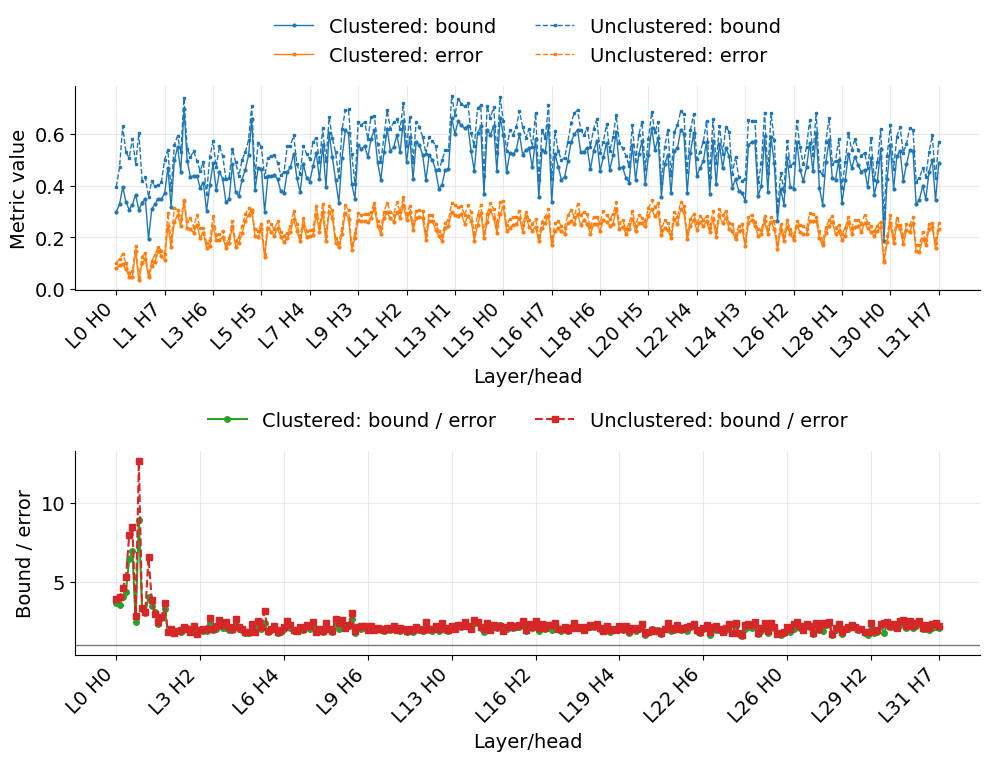

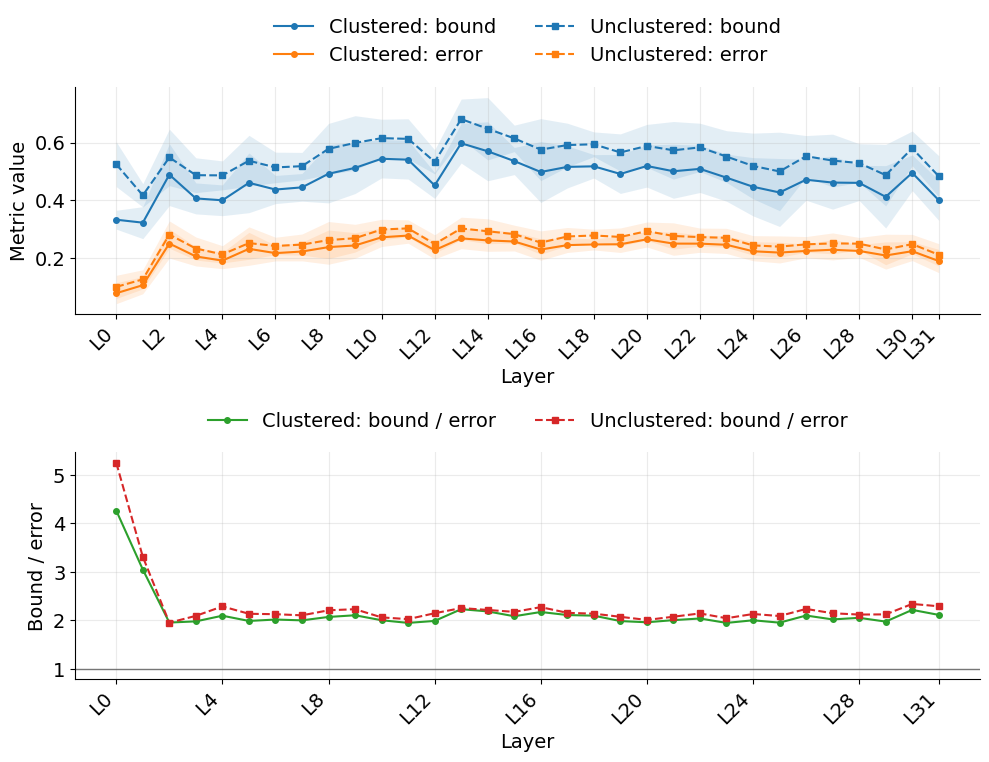

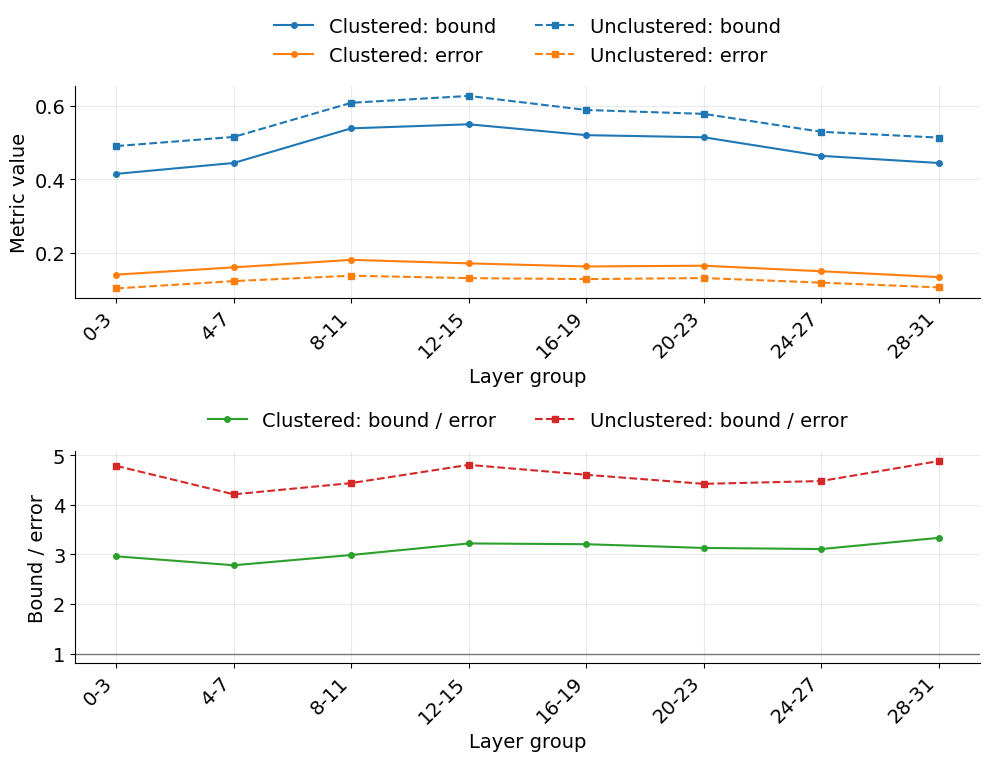

In [105]:

display_case_result(
    keys_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)

## Values, Row Clustering

In [106]:
values_rows = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 4096). Using rank 1.
  warnings.warn(


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_rows,256,0.786420,0.811679,0.568005,0.572631,0.140306,0.953368
1,values_xkv_rows,40,0.814333,0.833170,0.424478,0.426731,0.461735,0.888889
2,values_lrk_rows_n_clusters_1,256,0.891137,0.922806,0.631394,0.642685,0.213010,0.988571
3,values_xkv_rows_n_clusters_1,40,0.883943,0.905339,0.358285,0.353400,0.528061,0.944751


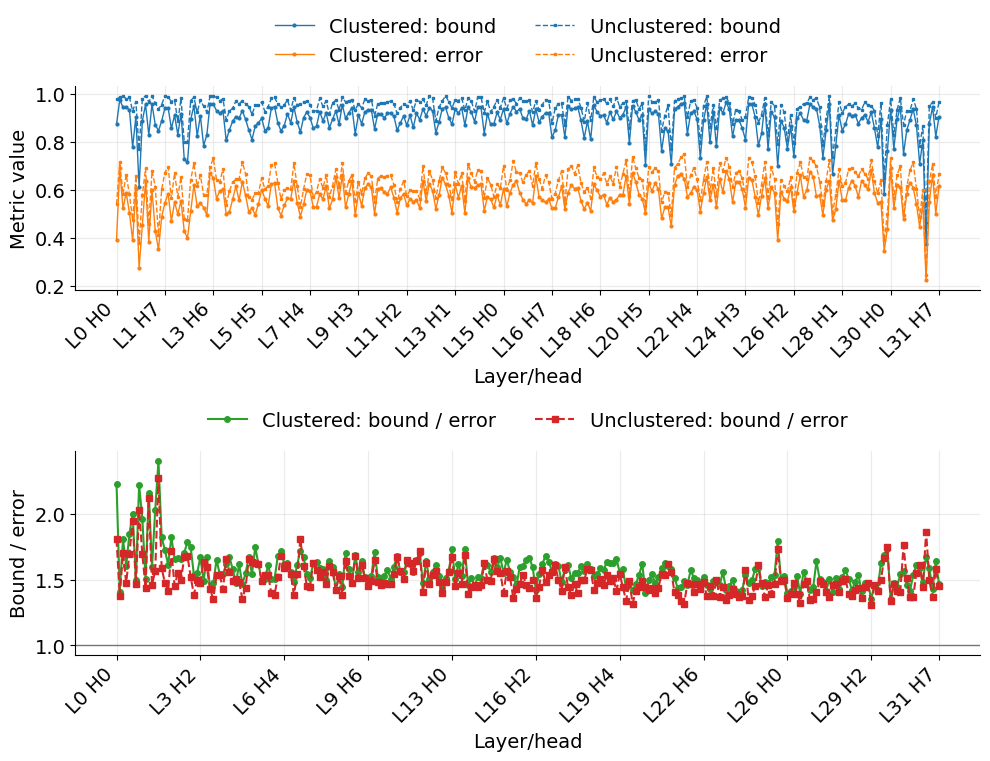

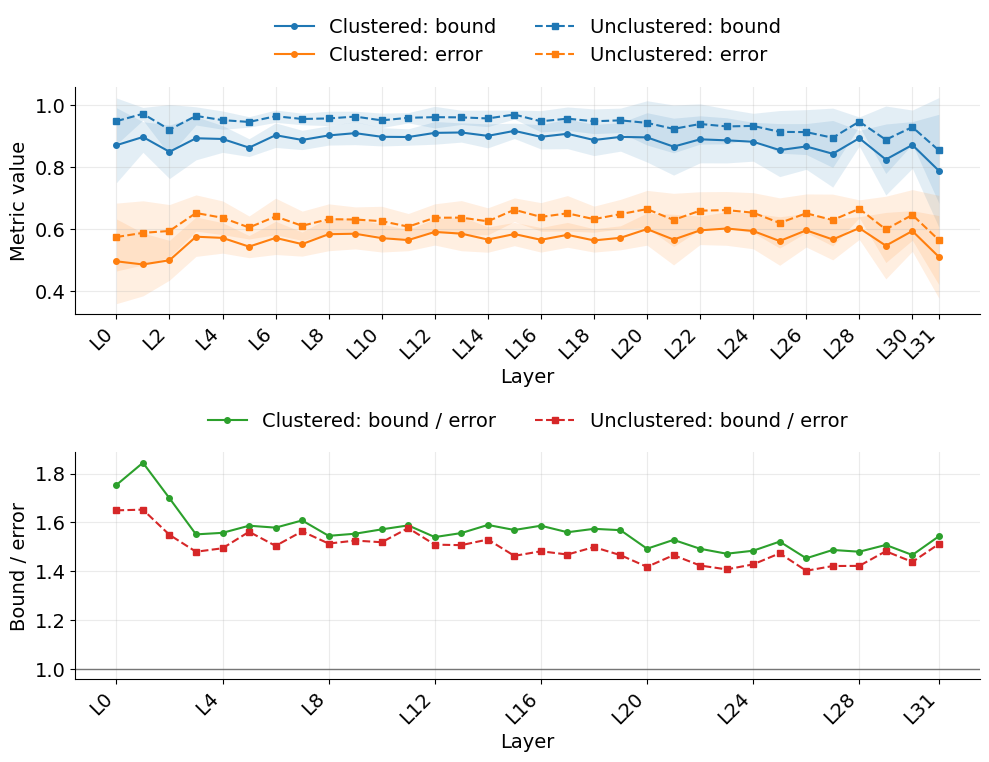

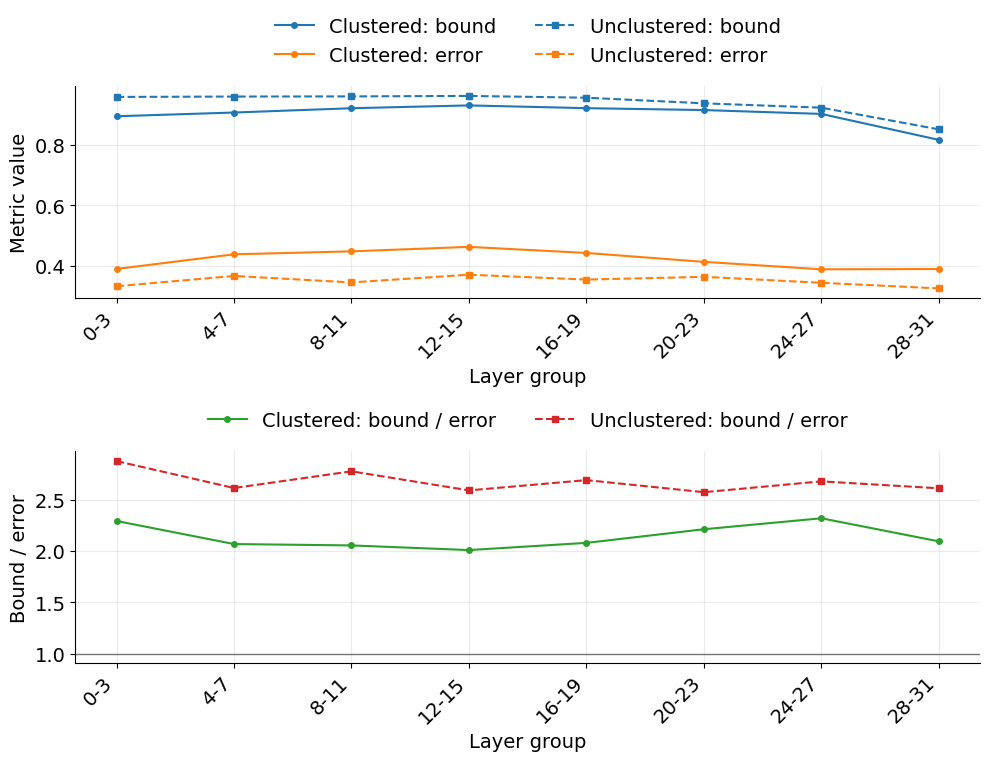

In [107]:
display_case_result(
    values_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)

## Keys, Column Clustering

In [108]:
keys_cols = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="cols",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 3770). Using rank 1.
  warnings.warn(


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_cols,256,0.992539,0.993650,0.251838,0.258953,0.932039,1.0
1,keys_xkv_cols,40,0.351505,0.345912,0.162695,0.166072,0.202206,0.5
2,keys_lrk_cols_n_clusters_1,256,0.992539,0.993650,0.251838,0.258953,0.932039,1.0
3,keys_xkv_cols_n_clusters_1,40,0.999446,1.000000,0.121584,0.123666,0.992481,1.0


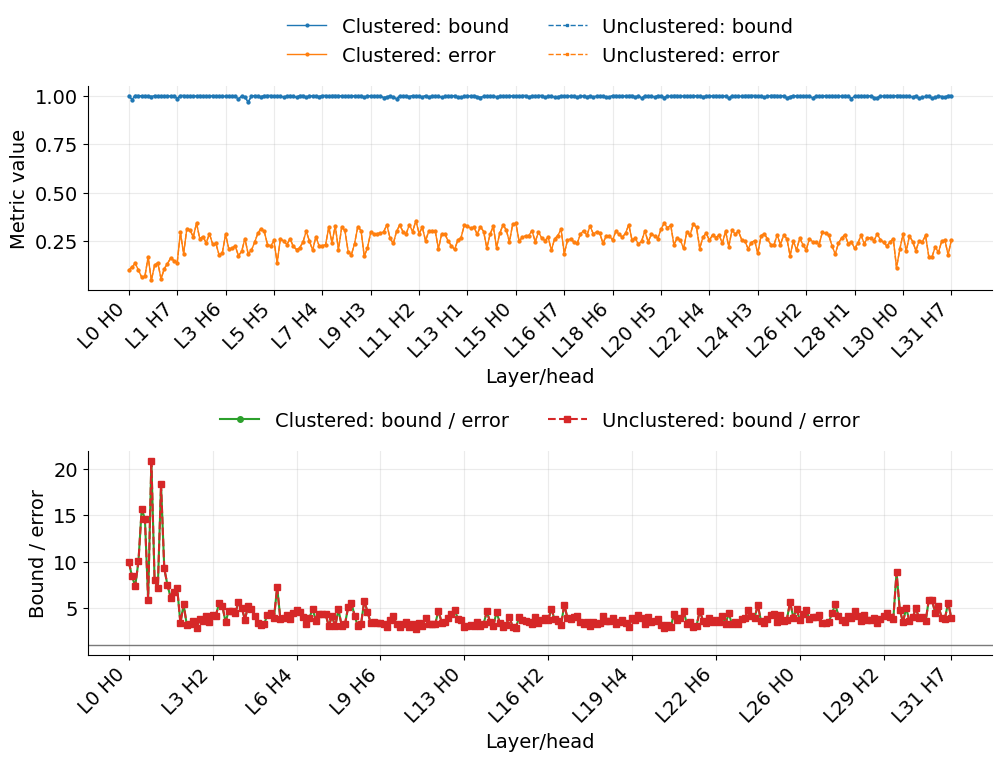

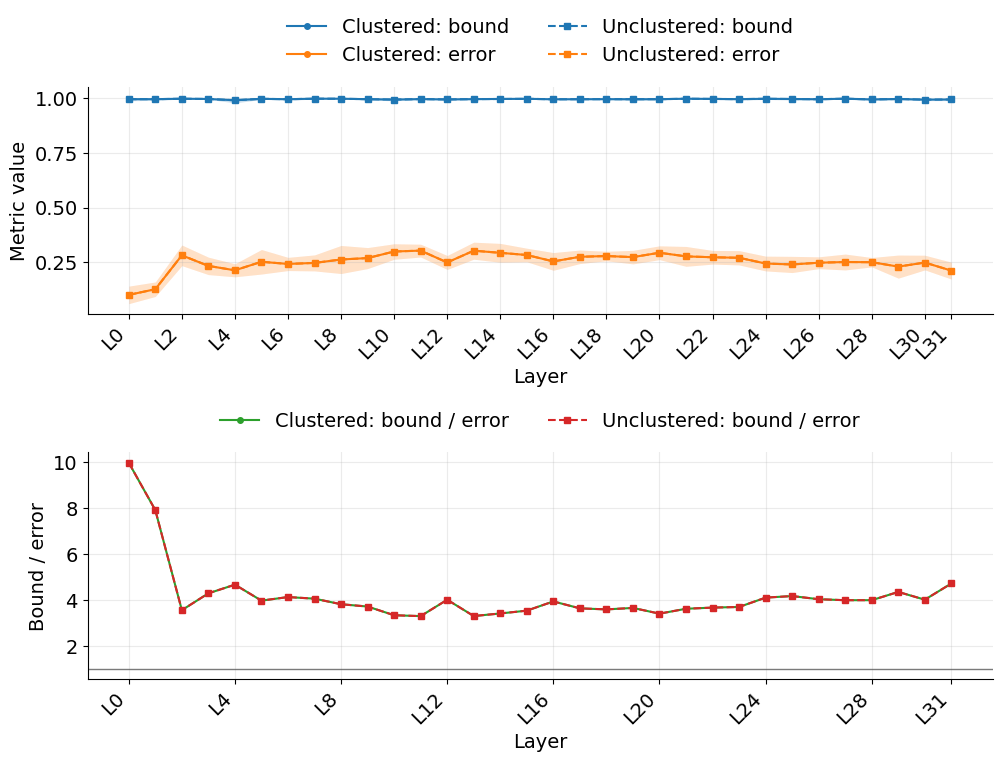

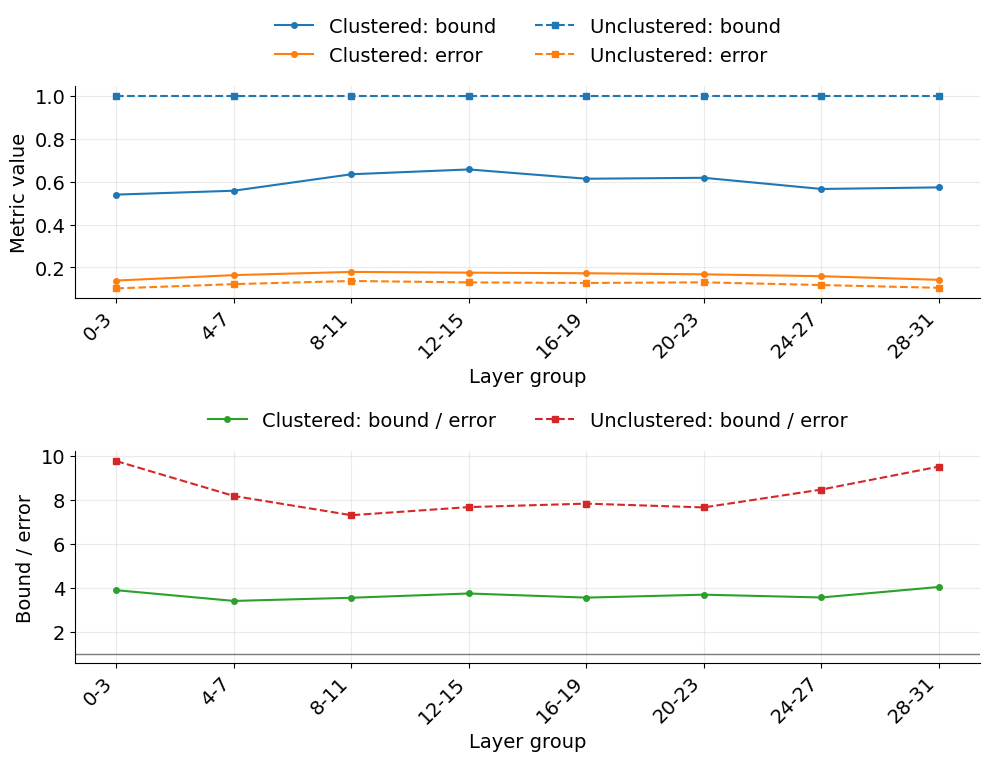

In [109]:
display_case_result(
    keys_cols,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)

## Values, Column Clustering

In [110]:
values_cols = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="cols",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 3770). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 3770). Using rank 1.
  warnings.warn(


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_cols,256,0.992107,0.992754,0.631382,0.642685,0.962963,1.000000
1,values_xkv_cols,40,0.888789,0.902296,0.453712,0.462633,0.543367,0.961326
2,values_lrk_cols_n_clusters_1,256,0.992107,0.992754,0.631382,0.642685,0.962963,1.000000
3,values_xkv_cols_n_clusters_1,40,0.999114,1.000000,0.358285,0.353400,0.993789,1.000000


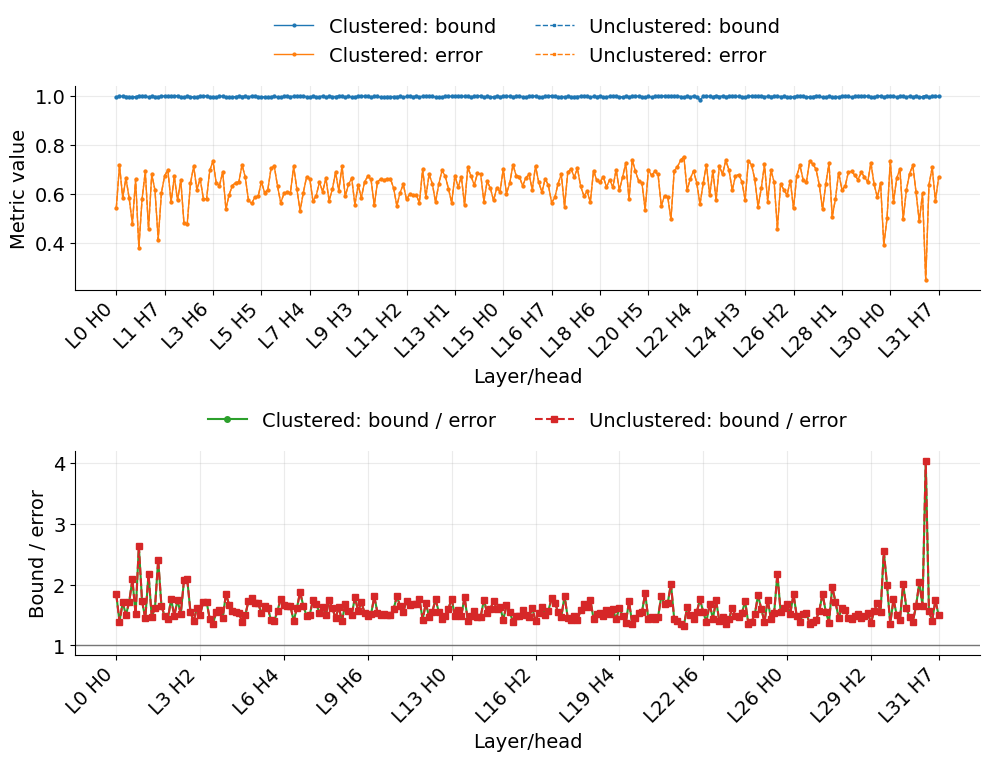

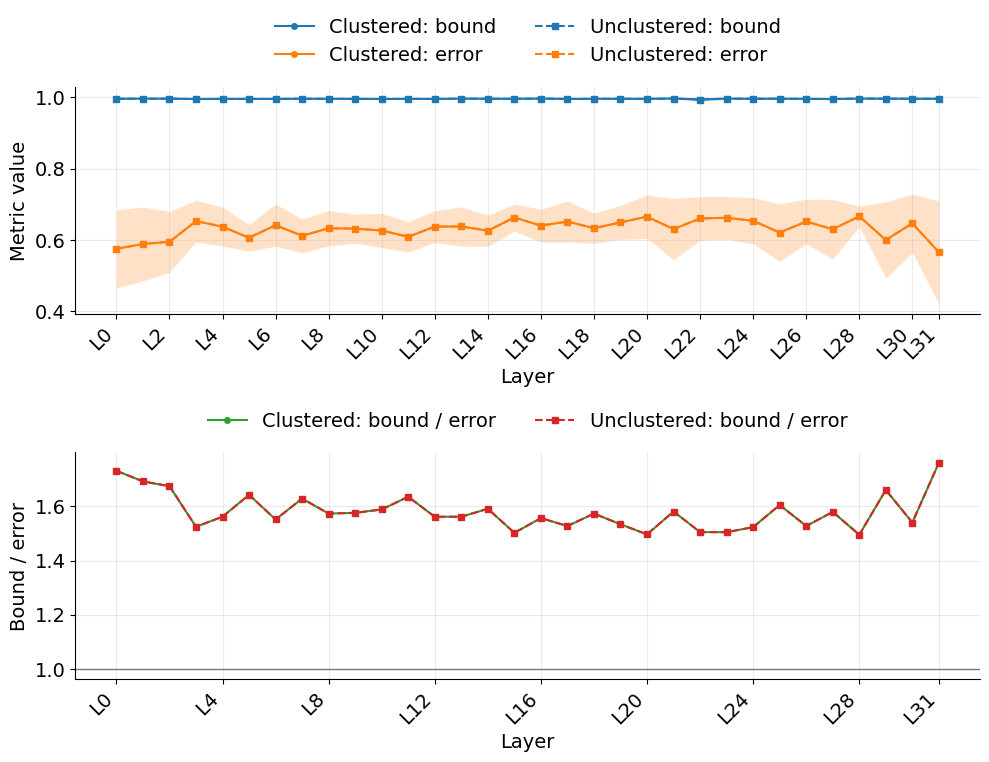

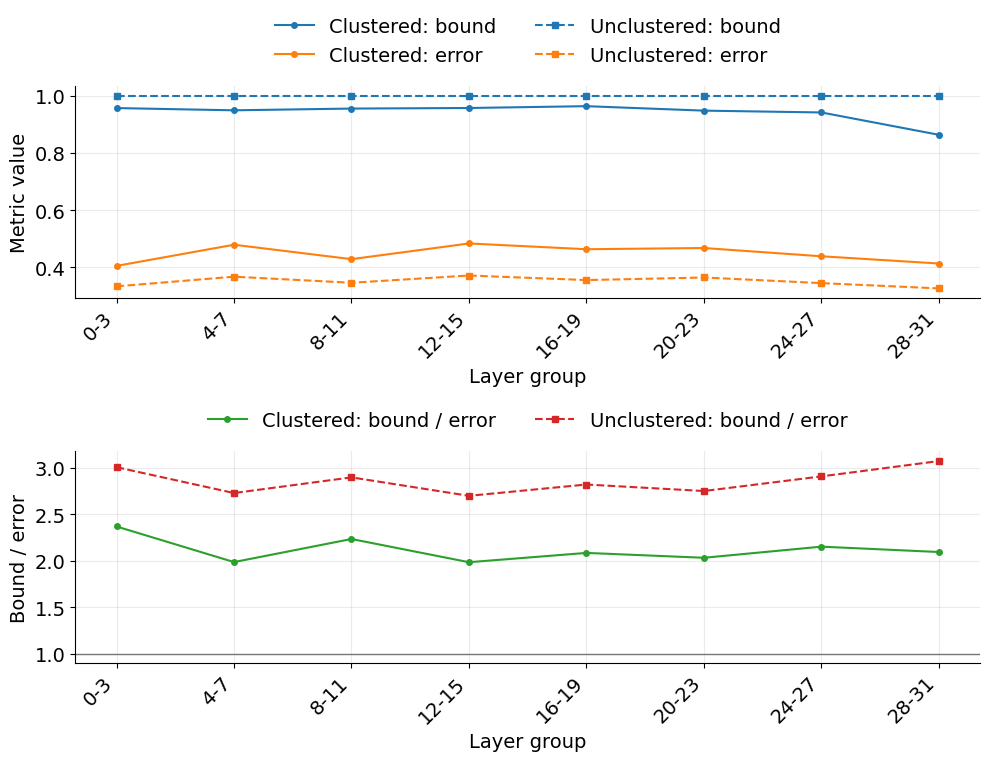

In [111]:
display_case_result(
    values_cols,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)